# Food Delivery Time Prediction using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [2]:
food_delivary = pd.read_csv(r"C:\Users\CJ\Downloads\Food_Delivery_Times.csv")

In [3]:
food_delivary.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
food_delivary.shape

(1000, 9)

In [5]:
food_delivary.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [6]:
print(food_delivary.columns)

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')


In [7]:
food_delivary[['Weather', 'Traffic_Level', 'Time_of_Day']].nunique()

Weather          5
Traffic_Level    3
Time_of_Day      4
dtype: int64

In [8]:
food_delivary = pd.get_dummies(food_delivary,columns=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type'],dtype = int )

In [9]:
print(food_delivary.columns)

Index(['Order_ID', 'Distance_km', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Delivery_Time_min', 'Weather_Clear',
       'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Traffic_Level_High', 'Traffic_Level_Low', 'Traffic_Level_Medium',
       'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Vehicle_Type_Scooter'],
      dtype='object')


In [10]:
food_delivary.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1
1,738,16.42,20,2.0,84,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0
2,741,9.52,28,1.0,59,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,661,7.44,5,1.0,37,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
4,412,19.03,16,5.0,68,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0


In [11]:
food_delivary.drop('Order_ID',axis =1,inplace = True)

In [12]:
food_delivary.corr()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_High,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
Distance_km,1.000000,-0.009037,-0.007842,0.780998,-0.036441,-0.026329,0.029239,0.072625,-0.001513,0.033691,0.013491,-0.049136,-0.002112,-0.015852,0.026059,-0.029308,-0.012405,0.023984,-0.007188
Preparation_Time_min,-0.009037,1.000000,-0.030830,0.307350,0.024892,-0.016514,0.016773,0.019119,-0.047268,-0.016918,0.026823,-0.020209,-0.015979,0.038528,-0.033526,0.007235,-0.018316,0.000529,0.019490
Courier_Experience_yrs,-0.007842,-0.030830,1.000000,-0.090433,-0.038735,-0.053904,0.072251,0.011713,0.033291,0.050141,-0.023996,-0.012342,0.033507,0.018391,-0.023440,-0.008281,0.004432,-0.005544,-0.000016
Delivery_Time_min,0.780998,0.307350,-0.090433,1.000000,-0.155770,0.041997,0.070271,0.154239,-0.018815,0.181309,-0.137392,-0.025789,-0.018586,0.021864,-0.018505,-0.021004,-0.007180,0.032752,-0.020444
Weather_Clear,-0.036441,0.024892,-0.038735,-0.155770,1.000000,-0.319105,-0.476727,-0.308641,-0.306876,-0.048310,-0.012406,0.039846,-0.006576,0.001277,0.009721,-0.006825,0.010379,-0.074086,0.052630
Weather_Foggy,-0.026329,-0.016514,-0.053904,0.041997,-0.319105,1.000000,-0.171546,-0.111062,-0.110427,0.005865,0.051103,-0.041617,-0.001839,-0.015751,-0.005159,0.050078,0.001257,-0.000706,-0.000760
Weather_Rainy,0.029239,0.016773,0.072251,0.070271,-0.476727,-0.171546,1.000000,-0.165921,-0.164972,0.023784,0.009536,-0.028288,0.011359,0.028505,-0.020598,-0.011924,-0.022891,0.026432,0.002119
Weather_Snowy,0.072625,0.019119,0.011713,0.154239,-0.308641,-0.111062,-0.165921,1.000000,-0.106805,0.007569,0.047605,-0.054242,-0.011599,0.026570,-0.013730,-0.002968,0.021686,0.051894,-0.068398
Weather_Windy,-0.001513,-0.047268,0.033291,-0.018815,-0.306876,-0.110427,-0.164972,-0.106805,1.000000,0.034890,-0.075192,0.045655,0.013068,-0.060621,0.039940,-0.026291,0.031991,0.010967,-0.044302
Traffic_Level_High,0.033691,-0.016918,0.050141,0.181309,-0.048310,0.005865,0.023784,0.007569,0.034890,1.000000,-0.390240,-0.396043,0.011441,-0.015031,0.007211,0.011314,0.004571,-0.015325,0.008247


In [13]:
food_delivary.drop('Time_of_Day_Afternoon',axis = 1,inplace = True)
food_delivary.drop('Time_of_Day_Evening',axis=1,inplace = True)
food_delivary.drop('Time_of_Day_Morning',axis=1,inplace = True)
food_delivary.drop('Time_of_Day_Night',axis=1,inplace = True)
food_delivary.drop('Vehicle_Type_Bike',axis=1,inplace = True)
food_delivary.drop('Vehicle_Type_Car',axis=1,inplace = True)
food_delivary.drop('Vehicle_Type_Scooter',axis=1,inplace = True)

In [14]:
x = food_delivary.drop('Delivery_Time_min',axis = 1)
y = food_delivary['Delivery_Time_min']

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42)

## Model Building
- Random Forest Regessor used

In [16]:
model = RandomForestRegressor(
    n_estimators = 200,
    max_depth = 10,
    min_samples_split = 10,
    min_samples_leaf = 4,
    random_state = 42)

model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [17]:
comparision = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})
print(comparision.head())
                    

     Actual  Predicted
521      32  34.128582
737      68  66.437759
740      39  41.351987
660      44  47.515247
411      85  85.206392


## Model Evaluation
- Mean Squared Error(MSE)
- Mean Absolu

In [18]:
mae = mean_absolute_error(y_test,y_pred)
print('MAE :',mae)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print('RMSE :', rmse )

MAE : 6.542954915179076
RMSE : 9.548328709219366


In [19]:
imp  = pd.Series(model.feature_importances_,index = x.columns)
imp = imp.sort_values(ascending = False)
print(imp)

Distance_km               0.759937
Preparation_Time_min      0.151357
Courier_Experience_yrs    0.031707
Traffic_Level_Low         0.014930
Traffic_Level_High        0.014097
Weather_Clear             0.011637
Weather_Snowy             0.004905
Weather_Foggy             0.004196
Weather_Rainy             0.004037
Traffic_Level_Medium      0.002818
Weather_Windy             0.000380
dtype: float64


In [20]:
print(x.isnull().sum())

Distance_km                0
Preparation_Time_min       0
Courier_Experience_yrs    30
Weather_Clear              0
Weather_Foggy              0
Weather_Rainy              0
Weather_Snowy              0
Weather_Windy              0
Traffic_Level_High         0
Traffic_Level_Low          0
Traffic_Level_Medium       0
dtype: int64


In [21]:
food_delivary["Courier_Experience_yrs"]=food_delivary["Courier_Experience_yrs"].fillna(food_delivary["Courier_Experience_yrs"].median())

In [22]:
x= x.fillna(x.median())

In [23]:
print(x.isnull().sum())

Distance_km               0
Preparation_Time_min      0
Courier_Experience_yrs    0
Weather_Clear             0
Weather_Foggy             0
Weather_Rainy             0
Weather_Snowy             0
Weather_Windy             0
Traffic_Level_High        0
Traffic_Level_Low         0
Traffic_Level_Medium      0
dtype: int64


In [24]:
x = food_delivary.drop('Delivery_Time_min',axis = 1)
y = food_delivary['Delivery_Time_min']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42)



from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [25]:
comparision = pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})
print(comparision.head())

mae = mean_absolute_error(y_test,y_pred)
print('MAE :',mae)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print('RMSE :', rmse )

     Actual  Predicted
521      32  34.286485
737      68  65.632924
740      39  47.528857
660      44  48.720174
411      85  81.650178
MAE : 6.383068232020318
RMSE : 9.286921009656588


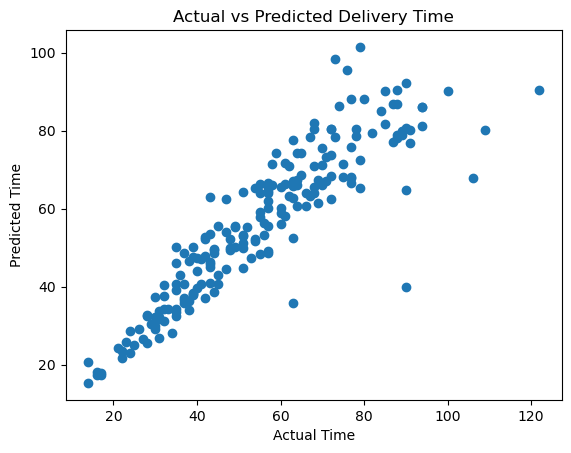

In [26]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Time")
plt.ylabel("Predicted Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

In [27]:
# Random Forest
rf_model = RandomForestRegressor()
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor()
gb_model.fit(x_train, y_train)
gb_pred = gb_model.predict(x_test)

In [28]:
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, gb_pred))

Random Forest MAE: 6.76535
Gradient Boosting MAE: 6.398167576252057
